
# Election Prediction Project
## Notebook 01 — Data Mapping, Harmonization and Merging

This notebook constructs the unified dataset for the election prediction project.

Notebook Objectives:



*   To map the political parties across the five election cycles into main voting blocs.
*   To create four target variables: Right_pct, Center_Left_pct, Haredi_pct, and Arab_pct.
*  To load and merge education, demographics, wage, unemployment, and welfare data by locality and year.
*   To join the locality characteristics with the election results.
*   To perform quality assurance, coverage, and duplication checks.
*   To export a unified dataset that will be used in the preprocessing notebook.



## 1. Imports and project configuration


In [1]:

from pathlib import Path
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)


In [2]:
# Repository-relative configuration (run notebooks from the notebooks/ folder):
# all paths stay relative, so the project runs on any machine straight after cloning.
REPO_ROOT = Path('..')

DATA_RAW_DIR = REPO_ROOT / 'data' / 'raw'
ELECTION_DIR = DATA_RAW_DIR / 'Election_data'
EDUCATION_DIR = DATA_RAW_DIR / 'Education_data'
DEMOGRAPHIC_DIR = DATA_RAW_DIR / 'Demographic_data'
INCOME_DIR = DATA_RAW_DIR / 'Average_income'
UNEMPLOYMENT_DIR = DATA_RAW_DIR / 'Unemployment_data'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MERGED_OUTPUT_PATH = PROCESSED_DIR / 'merged_elections_demographics.csv'
ELECTION_TARGETS_OUTPUT_PATH = PROCESSED_DIR / 'election_targets_by_locality.csv'
COVERAGE_OUTPUT_PATH = PROCESSED_DIR / 'coverage_by_election.csv'

print(f'Raw-data directory: {DATA_RAW_DIR}')
print(f'Processed-data directory: {PROCESSED_DIR}')


Raw-data directory: ..\data\raw
Processed-data directory: ..\data\processed



## 2. Party-to-block mapping

- `Right`
- `Center_Left`
- `Haredi`
- `Arab`

Parties that do not appear in the mapping are not discarded. Their votes are aggregated under Other, allowing us to track how many votes are not included in the four main target variables

In [3]:
# Bloc definitions are coalitional, not ideological: 'Right' ~ the Netanyahu
# bloc without the Haredi parties, 'Center_Left' ~ the change bloc of 2019-2022.
# Yisrael Beiteinu refused to sit with the Netanyahu bloc in all five cycles and
# is therefore assigned to Center_Left (primary definition).
# Set to 'Right' to reproduce the ideological-tagging sensitivity run.
YISRAEL_BEITEINU_BLOC = 'Center_Left'

# Each party appears once, with its bloc and every ballot letter it used in
# Knesset 21-25. A letter may appear under two parties (e.g. 'ב') only when both
# map to the same bloc - the derivation below enforces this.
PARTY_DEFINITIONS = {
    # Right and center-right
    'הליכוד': ('Right', ['מחל']),
    'איחוד מפלגות הימין (21) / ימינה (22-23)': ('Right', ['טב']),
    'ימינה (24) / הבית היהודי (25)': ('Right', ['ב']),
    'הציונות הדתית': ('Right', ['ט']),
    'תקווה חדשה': ('Right', ['ת']),
    'כולנו': ('Right', ['כ']),
    'הימין החדש': ('Right', ['נ']),
    'זהות': ('Right', ['ז']),
    'עוצמה יהודית (ריצה עצמאית, 22-23)': ('Right', ['כף', 'נץ']),

    # Center-left
    'כחול לבן (21-23) / יש עתיד (24-25)': ('Center_Left', ['פה']),
    'העבודה (לבדה ובריצות משותפות)': ('Center_Left', ['אמת']),
    'מרצ / המחנה הדמוקרטי': ('Center_Left', ['מרצ']),
    'כחול לבן (24) / המחנה הממלכתי (25)': ('Center_Left', ['כן']),
    'גשר': ('Center_Left', ['נר']),
    'ישראל ביתנו': (YISRAEL_BEITEINU_BLOC, ['ל']),

    # Haredi
    'ש"ס': ('Haredi', ['שס']),
    'יהדות התורה': ('Haredi', ['ג']),

    # Arab parties
    'הרשימה המשותפת': ('Arab', ['ודעם']),
    'רע"מ': ('Arab', ['עם']),
    'חד"ש-תע"ל': ('Arab', ['ום']),
    'בל"ד': ('Arab', ['ד']),
    'רע"מ-בל"ד': ('Arab', ['דעם']),
}

# Letters identified but intentionally left unmapped (counted as Other):
#   'זץ' (Knesset 22, 0.33%) - דע"ם, מפלגה יהודית-ערבית ללא שיוך גושי מובהק.
#   'ר'  (Knesset 24, 0.39%) - רפ"א, מפלגת מחאה בנושאי בריאות ללא שיוך גושי.
#   'צי' (Knesset 24, <0.1%) - רשימה זעירה שלא זוהתה.
# Note: the letter 'ז' was reused by a tiny list in Knesset 24 (<0.1%); the
# mapping attributes it to Zehut (Knesset 21, 2.74%) and the noise is negligible.

PARTY_TO_BLOCK = {}
for party_name, (bloc, letters) in PARTY_DEFINITIONS.items():
    for letter in letters:
        existing_bloc = PARTY_TO_BLOCK.get(letter)
        if existing_bloc is not None and existing_bloc != bloc:
            raise ValueError(
                f'The letter {letter} is mapped to two different blocs: '
                f'{existing_bloc} and {bloc}.'
            )
        PARTY_TO_BLOCK[letter] = bloc

MODELED_BLOCKS = ['Right', 'Center_Left', 'Haredi', 'Arab']
TARGET_COLUMNS = [f'{block}_pct' for block in MODELED_BLOCKS]

ELECTION_FILES = {
    'Knesset_21': 'Knesset_21_Election_Results_2019_By_Locality.csv',
    'Knesset_22': 'Knesset_22_Election_Results_2019_By_Locality.csv',
    'Knesset_23': 'Knesset_23_Election_Results_2020_By_Locality.csv',
    'Knesset_24': 'Knesset_24_Election_Results_2021_By_Locality.csv',
    'Knesset_25': 'Knesset_25_Election_Results_2022_By_Locality.csv',
}

KNESSET_TO_YEAR = {
    'Knesset_21': 2019,
    'Knesset_22': 2019,
    'Knesset_23': 2020,
    'Knesset_24': 2021,
    'Knesset_25': 2022,
}

print(f'Parties defined: {len(PARTY_DEFINITIONS)} | mapped ballot letters: {len(PARTY_TO_BLOCK)}')
print(f'Yisrael Beiteinu bloc in this run: {YISRAEL_BEITEINU_BLOC}')


Parties defined: 22 | mapped ballot letters: 23
Yisrael Beiteinu bloc in this run: Center_Left


In [4]:

def first_existing_column(df, candidates, required=True):
    """Return the first column from candidates that exists in the dataframe."""
    for column in candidates:
        if column in df.columns:
            return column

    if required:
        raise KeyError(f'None of the required columns were found: {candidates}')

    return None


def normalize_locality_symbol(series):
    """Convert locality identifiers to a consistent string representation."""
    numeric_values = pd.to_numeric(series, errors='coerce').astype('Int64')
    return numeric_values.astype('string')


def aggregate_votes_by_block(df_elections, election_name):
    """Aggregate raw party votes into four modeled voting blocks."""
    df = df_elections.copy()

    symbol_column = first_existing_column(
        df,
        ['סמל ישוב', 'סמל יישוב', 'סמל היישוב']
    )
    name_column = first_existing_column(
        df,
        ['שם ישוב', 'שם יישוב', 'שם היישוב'],
        required=False
    )

    if 'כשרים' not in df.columns:
        raise KeyError(
            f"The file for {election_name} does not contain the valid-votes column 'כשרים'."
        )

    df['כשרים'] = pd.to_numeric(df['כשרים'], errors='coerce')

    if df['כשרים'].isna().any():
        raise ValueError(
            f'{election_name}: invalid or missing values were found in the valid-votes column.'
        )

    for block in MODELED_BLOCKS:
        df[block] = 0.0

    mapped_party_columns = [
        column for column in PARTY_TO_BLOCK
        if column in df.columns
    ]

    for column in mapped_party_columns:
        numeric_votes = pd.to_numeric(df[column], errors='coerce').fillna(0)
        df[PARTY_TO_BLOCK[column]] += numeric_votes

    df['total_main_blocks'] = df[MODELED_BLOCKS].sum(axis=1)
    df['Other'] = df['כשרים'] - df['total_main_blocks']

    invalid_other_rows = df['Other'] < 0
    if invalid_other_rows.any():
        raise ValueError(
            f'{election_name}: {invalid_other_rows.sum()} rows contain more mapped votes than valid votes. '
            'Review the party mapping before continuing.'
        )

    df['Other_raw_pct'] = np.where(
        df['כשרים'] > 0,
        df['Other'] / df['כשרים'] * 100,
        np.nan
    )

    for block in MODELED_BLOCKS:
        df[f'{block}_pct'] = np.where(
            df['total_main_blocks'] > 0,
            df[block] / df['total_main_blocks'] * 100,
            np.nan
        )

    output = pd.DataFrame({
        'locality_symbol': normalize_locality_symbol(df[symbol_column]),
        'valid_votes': df['כשרים'],
        'Right': df['Right'],
        'Center_Left': df['Center_Left'],
        'Haredi': df['Haredi'],
        'Arab': df['Arab'],
        'Other': df['Other'],
        'total_main_blocks': df['total_main_blocks'],
        'Right_pct': df['Right_pct'],
        'Center_Left_pct': df['Center_Left_pct'],
        'Haredi_pct': df['Haredi_pct'],
        'Arab_pct': df['Arab_pct'],
        'Other_raw_pct': df['Other_raw_pct'],
    })

    if name_column is not None:
        output['election_locality_name'] = df[name_column].astype('string').str.strip()

    output['target_election'] = election_name
    output['year'] = KNESSET_TO_YEAR[election_name]

    duplicate_count = output.duplicated(subset=['locality_symbol']).sum()
    if duplicate_count > 0:
        raise ValueError(
            f'{election_name}: found {duplicate_count} duplicate locality rows.'
        )

    return output



## 3. Loading and validating election results


In [5]:

def read_election_csv(file_path):
    """Read an election CSV while handling the common Hebrew encodings."""
    try:
        return pd.read_csv(file_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding='cp1255')


def load_all_elections(election_dir):
    """Load and aggregate all configured election files."""
    processed_elections = {}

    for election_name, filename in ELECTION_FILES.items():
        file_path = election_dir / filename

        if not file_path.exists():
            raise FileNotFoundError(f'Missing election file: {file_path}')

        raw_df = read_election_csv(file_path)
        processed_df = aggregate_votes_by_block(raw_df, election_name)
        processed_elections[election_name] = processed_df

        print(
            f'{election_name}: '
            f'{processed_df.shape[0]} localities, '
            f'{processed_df["valid_votes"].sum():,.0f} valid votes'
        )

    return processed_elections


elections_data = load_all_elections(ELECTION_DIR)


Knesset_21: 1214 localities, 4,309,270 valid votes
Knesset_22: 1214 localities, 4,436,806 valid votes
Knesset_23: 1214 localities, 4,590,062 valid votes
Knesset_24: 1215 localities, 4,410,052 valid votes
Knesset_25: 1216 localities, 4,764,742 valid votes


In [6]:
# Mapping audit: quantify unmapped ballot letters per
# election and fail loudly if any single unmapped letter crosses the threshold.
UNMAPPED_ALERT_THRESHOLD_PCT = 1.0

NON_PARTY_COLUMNS = {
    'סמל ועדה', 'שם ישוב', 'שם יישוב', 'סמל ישוב', 'סמל יישוב',
    'בזב', 'מצביעים', 'פסולים', 'כשרים', 'ריכוז', 'שופט', 'ברזל',
}


def audit_party_mapping(election_dir):
    for election_name, filename in ELECTION_FILES.items():
        raw_df = read_election_csv(election_dir / filename)
        valid_total = pd.to_numeric(raw_df['כשרים'], errors='coerce').sum()

        unmapped_rows = []
        for column in raw_df.columns:
            if column in NON_PARTY_COLUMNS or column in PARTY_TO_BLOCK:
                continue
            votes = pd.to_numeric(raw_df[column], errors='coerce').sum()
            share_pct = votes / valid_total * 100
            if share_pct >= 0.05:
                unmapped_rows.append((column, share_pct))

        unmapped_rows.sort(key=lambda row: -row[1])
        total_unmapped_pct = sum(share for _, share in unmapped_rows)

        listed = ', '.join(f'{col} ({share:.2f}%)' for col, share in unmapped_rows)
        print(f'{election_name}: unmapped >= 0.05%: [{listed}] '
              f'| total {total_unmapped_pct:.2f}%')

        for column, share_pct in unmapped_rows:
            if share_pct > UNMAPPED_ALERT_THRESHOLD_PCT:
                raise ValueError(
                    f'{election_name}: unmapped letter {column} holds '
                    f'{share_pct:.2f}% of valid votes - above the '
                    f'{UNMAPPED_ALERT_THRESHOLD_PCT}% threshold. '
                    'Update PARTY_DEFINITIONS before continuing.'
                )


audit_party_mapping(ELECTION_DIR)


Knesset_21: unmapped >= 0.05%: [ן (0.11%), ר (0.10%), צק (0.09%), ק (0.08%), זץ (0.06%)] | total 0.42%
Knesset_22: unmapped >= 0.05%: [זץ (0.33%), כי (0.13%), יז (0.10%), צ (0.07%), רק (0.05%)] | total 0.69%
Knesset_23: unmapped >= 0.05%: [] | total 0.00%
Knesset_24: unmapped >= 0.05%: [יז (0.79%), ר (0.39%)] | total 1.18%
Knesset_25: unmapped >= 0.05%: [אצ (0.33%), קץ (0.31%), יז (0.29%), צ (0.18%)] | total 1.12%


In [7]:

def build_national_election_summary(elections_dictionary):
    """Build national raw and modeled-block summaries for quality control."""
    rows = []

    for election_name, df in elections_dictionary.items():
        total_valid_votes = df['valid_votes'].sum()
        total_modeled_votes = df['total_main_blocks'].sum()

        row = {
            'target_election': election_name,
            'year': KNESSET_TO_YEAR[election_name],
            'valid_votes': total_valid_votes,
            'modeled_votes': total_modeled_votes,
            'modeled_vote_coverage_pct': total_modeled_votes / total_valid_votes * 100,
            'Other_pct_of_valid_votes': df['Other'].sum() / total_valid_votes * 100,
        }

        for block in MODELED_BLOCKS:
            row[f'{block}_pct_of_valid_votes'] = df[block].sum() / total_valid_votes * 100
            row[f'{block}_pct_normalized'] = df[block].sum() / total_modeled_votes * 100

        rows.append(row)

    return pd.DataFrame(rows)


national_election_summary = build_national_election_summary(elections_data)
national_election_summary.round(2)


,target_election,year,valid_votes,modeled_votes,modeled_vote_coverage_pct,Other_pct_of_valid_votes,Right_pct_of_valid_votes,Right_pct_normalized,Center_Left_pct_of_valid_votes,Center_Left_pct_normalized,Haredi_pct_of_valid_votes,Haredi_pct_normalized,Arab_pct_of_valid_votes,Arab_pct_normalized
0,Knesset_21,2019,4309270,4277978.0,99.27,0.73,39.74,40.03,39.94,40.23,11.77,11.86,7.82,7.88
1,Knesset_22,2019,4436806,4395937.0,99.08,0.92,32.91,33.21,42.07,42.46,13.50,13.63,10.60,10.70
2,Knesset_23,2020,4590062,4580445.0,99.79,0.21,35.29,35.36,38.17,38.25,13.67,13.69,12.67,12.70
3,Knesset_24,2021,4410052,4346844.0,98.57,1.43,40.29,40.88,36.87,37.41,12.80,12.98,8.61,8.73
4,Knesset_25,2022,4764742,4696835.0,98.57,1.43,35.50,36.01,38.21,38.76,14.13,14.33,10.73,10.89


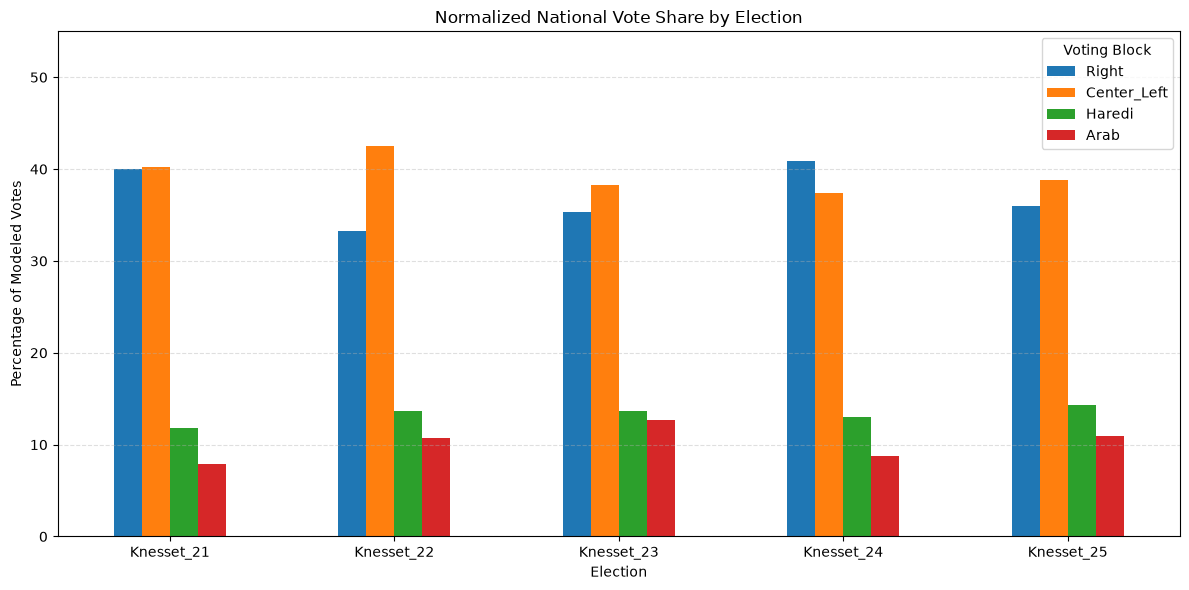

In [8]:

# Plot normalized national block shares using a consistent denominator
plot_columns = [f'{block}_pct_normalized' for block in MODELED_BLOCKS]
plot_df = national_election_summary.set_index('target_election')[plot_columns].copy()
plot_df.columns = MODELED_BLOCKS

ax = plot_df.plot(kind='bar', figsize=(12, 6))
ax.set_title('Normalized National Vote Share by Election')
ax.set_xlabel('Election')
ax.set_ylabel('Percentage of Modeled Votes')
ax.set_ylim(0, max(55, plot_df.to_numpy().max() * 1.15))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(title='Voting Block')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## 4. Creating the unified election-target table



In [9]:

unified_elections_data = pd.concat(
    elections_data.values(),
    ignore_index=True
)

unified_elections_data['year'] = pd.to_numeric(
    unified_elections_data['year'],
    errors='raise'
).astype(int)

# Quality checks for the target table
if unified_elections_data[TARGET_COLUMNS].isna().any().any():
    raise ValueError('Missing target values were found in the unified election table.')

if not np.allclose(
    unified_elections_data[TARGET_COLUMNS].sum(axis=1),
    100,
    atol=1e-6
):
    raise ValueError('At least one target row does not sum to 100%.')

if unified_elections_data.duplicated(
    subset=['locality_symbol', 'target_election']
).any():
    raise ValueError('Duplicate locality-election rows were found.')

print(f'Unified election table shape: {unified_elections_data.shape}')
print(f'Unique localities: {unified_elections_data["locality_symbol"].nunique()}')
print('Elections included:', unified_elections_data['target_election'].unique().tolist())

unified_elections_data.head()


Unified election table shape: (6073, 16)
Unique localities: 1221
Elections included: ['Knesset_21', 'Knesset_22', 'Knesset_23', 'Knesset_24', 'Knesset_25']


,locality_symbol,valid_votes,Right,Center_Left,Haredi,Arab,Other,total_main_blocks,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct,Other_raw_pct,election_locality_name,target_election,year
0,7,371,196.0,139.0,35.0,0.0,1.0,370.0,52.972973,37.567568,9.459459,0.0,0.269542,שחר,Knesset_21,2019
1,10,235,148.0,11.0,76.0,0.0,0.0,235.0,62.978723,4.680851,32.340426,0.0,0.000000,תירוש,Knesset_21,2019
2,11,288,130.0,156.0,2.0,0.0,0.0,288.0,45.138889,54.166667,0.694444,0.0,0.000000,"ניר ח""ן",Knesset_21,2019
3,13,403,75.0,320.0,4.0,0.0,4.0,399.0,18.796992,80.200501,1.002506,0.0,0.992556,חצבה,Knesset_21,2019
4,15,215,175.0,8.0,29.0,0.0,3.0,212.0,82.547170,3.773585,13.679245,0.0,1.395349,נועם,Knesset_21,2019



## 5. CBS data sources



In [10]:

def read_tabular_file(file_path, dtype=None):
    """Read Excel or CSV files using one shared interface."""
    suffix = file_path.suffix.lower()

    if suffix in {'.xlsx', '.xls'}:
        return pd.read_excel(file_path, dtype=dtype)

    if suffix == '.csv':
        try:
            return pd.read_csv(file_path, dtype=dtype, encoding='utf-8-sig')
        except UnicodeDecodeError:
            return pd.read_csv(file_path, dtype=dtype, encoding='cp1255')

    raise ValueError(f'Unsupported file type: {file_path}')


def clean_feature_column_name(column_name, file_year):
    """Remove the file's own year label (and Hebrew year forms) without
    touching meaningful numbers such as 'עולי 1990+'."""
    clean_name = str(column_name).replace('\n', ' ')
    clean_name = re.sub(r'\.\d+$', '', clean_name)
    next_year_short = str(file_year + 1)[-2:]
    clean_name = clean_name.replace(f'{file_year}/{next_year_short}', ' ')
    clean_name = clean_name.replace(str(file_year), ' ')
    clean_name = re.sub(r'תש[א-ת]"?[א-ת]?', '', clean_name)
    clean_name = ' '.join(clean_name.split())
    return clean_name


def coalesce_duplicate_columns(df):
    """Combine duplicate columns by taking the first non-missing value per row."""
    result = pd.DataFrame(index=df.index)

    for column in dict.fromkeys(df.columns):
        matching_columns = df.loc[:, df.columns == column]
        result[column] = matching_columns.bfill(axis=1).iloc[:, 0]

    return result


def standardize_locality_columns(df, source_name):
    """Standardize locality identifier and preserve one source-specific locality name."""
    df = df.copy()

    symbol_candidates = [
        'locality_symbol',
        'סמל היישוב',
        'סמל יישוב',
        'סמל ישוב',
    ]
    existing_symbol_columns = [
        column for column in symbol_candidates
        if column in df.columns
    ]

    if not existing_symbol_columns:
        raise KeyError(f'{source_name}: no locality-symbol column was found.')

    for column in existing_symbol_columns:
        df.rename(columns={column: 'locality_symbol'}, inplace=True)

    name_candidates = ['שם היישוב', 'שם יישוב', 'שם ישוב']
    existing_name_columns = [
        column for column in name_candidates
        if column in df.columns
    ]

    standardized_name_column = f'{source_name}_locality_name'
    for column in existing_name_columns:
        df.rename(columns={column: standardized_name_column}, inplace=True)

    df = coalesce_duplicate_columns(df)
    df['locality_symbol'] = normalize_locality_symbol(df['locality_symbol'])

    if standardized_name_column in df.columns:
        df[standardized_name_column] = (
            df[standardized_name_column]
            .astype('string')
            .str.strip()
        )

    return df


def clean_source_column_names(df, file_year):
    """Clean feature names while preserving key and locality-name columns."""
    protected_columns = {
        'locality_symbol',
        'year',
    }
    protected_columns.update(
        column for column in df.columns
        if column.endswith('_locality_name')
    )

    rename_mapping = {
        column: clean_feature_column_name(column, file_year)
        for column in df.columns
        if column not in protected_columns
    }

    df = df.rename(columns=rename_mapping)
    return coalesce_duplicate_columns(df)


def standardize_source_keys(df):
    """Standardize the merge keys."""
    df = df.copy()
    df['locality_symbol'] = normalize_locality_symbol(df['locality_symbol'])
    df['year'] = pd.to_numeric(df['year'], errors='raise').astype(int)
    return df


def report_source_quality(df, source_name):
    """Print a compact quality report for one source table."""
    duplicate_count = df.duplicated(
        subset=['locality_symbol', 'year']
    ).sum()

    missing_summary = (
        df.isna().mean()
        .sort_values(ascending=False)
        .head(10)
        .mul(100)
    )

    print(f'\n{source_name}')
    print('-' * len(source_name))
    print(f'Shape: {df.shape}')
    print(f'Years: {sorted(df["year"].dropna().unique().tolist())}')
    print(f'Unique localities: {df["locality_symbol"].nunique()}')
    print(f'Duplicate locality-year rows: {duplicate_count}')
    print('Top missing-rate columns (%):')
    print(missing_summary.round(2))

    if duplicate_count > 0:
        raise ValueError(
            f'{source_name}: duplicate locality-year rows must be resolved before merging.'
        )



## 6. Education data



In [11]:

def load_education_data(folder_path):
    """Load and harmonize all annual education files."""
    annual_tables = []
    files = sorted(folder_path.glob('Education_*.xlsx'))

    if not files:
        raise FileNotFoundError(f'No education files were found in {folder_path}')

    for file_path in files:
        year_match = re.search(r'\d{4}', file_path.name)
        if not year_match:
            raise ValueError(f'Could not extract a year from {file_path.name}')

        year = int(year_match.group())
        df = read_tabular_file(file_path, dtype=str)
        df = standardize_locality_columns(df, 'education')
        df = clean_source_column_names(df, year)
        df['year'] = year
        df = standardize_source_keys(df)
        annual_tables.append(df)

    return pd.concat(annual_tables, ignore_index=True, sort=False)


all_education_data = load_education_data(EDUCATION_DIR)
report_source_quality(all_education_data, 'Education data')
all_education_data.head()



Education data
--------------
Shape: (998, 42)
Years: [2019, 2020, 2021, 2022, 2023]
Unique localities: 204
Duplicate locality-year rows: 0
Top missing-rate columns (%):
locality_symbol                     0.0
education_locality_name             0.0
ילדים בגנים של משרד החינוך סה"כ     0.0
ילדים בגנים של משרד החינוך גיל 3    0.0
ילדים בגנים של משרד החינוך גיל 4    0.0
ילדים בגנים של משרד החינוך גיל 5    0.0
ילדים בגנים של משרד החינוך גיל 6    0.0
בתי ספר סה"כ                        0.0
בתי ספר יסודיים                     0.0
בתי ספר על-יסודיים                  0.0
dtype: float64


,locality_symbol,education_locality_name,"ילדים בגנים של משרד החינוך סה""כ",ילדים בגנים של משרד החינוך גיל 3,ילדים בגנים של משרד החינוך גיל 4,ילדים בגנים של משרד החינוך גיל 5,ילדים בגנים של משרד החינוך גיל 6,"בתי ספר סה""כ",בתי ספר יסודיים,בתי ספר על-יסודיים,בתי ספר חטיבות ביניים,בתי ספר תיכוניים,"כיתות סה""כ",כיתות בבתי ספר יסודיים,כיתות בבתי ספר על-יסודיים,...,אחוז זכאים לתעודת בגרות שעמדו בדרישות הסף של האוניברסיטאות מבין תלמידי כיתות יב,השכלה גבוהה אחוז בעלי תארים מישראל מתוך אוכלוסיית בני 55-35,השכלה גבוהה אחוז הנכנסים להשכלה גבוהה בתוך 8 שנים בקרב תלמידי יב,השכלה גבוהה אחוז סטודנטים מתוך אוכלוסיית בני 25-20,השכלה גבוהה אחוז סטודנטים מתוך כלל האוכלוסייה,עובדי הוראה מספר עובדי הוראה,עובדי הוראה ממוצע שעות עבודה לשבוע,עובדי הוראה אחוז עובדי הוראה חדשים,עובדי הוראה אחוז שעות היעדרות מסך שעות עבודה שנתיות,עובדי הוראה ממוצע שנות ותק מוכרות בהוראה,עובדי הוראה אחוז בעלי דרגת שכר תואר שני ומעלה,עובדי הוראה אחוז עובדי הוראה משתלמים מכלל עובדי הוראה,עובדי הוראה ממוצע תלמידים למורה,עובדי הוראה ממוצע שעות עבודה שבועיות לתלמיד,year
0,472,אבו גוש,371,125,136,106,4,5,4,4,1,3,71,38,33,...,37.17,13.03,..,21.45,3.74,183,30.3,8.05,6.4,11.2,33.33,0.9,9.91,3.06,2019
1,473,אבו סנאן,639,224,209,194,12,7,4,6,3,3,108,56,52,...,52.56,12.09,28.5,11.6,2.32,293,31.2,4.9,6.6,18.2,32.08,0.8,10.11,3.12,2019
2,182,אבן יהודה,706,163,228,280,35,7,5,4,1,3,141,78,63,...,76.89,55.59,46.1,12.65,3.03,318,30.1,7.33,6.3,15.7,44.03,0.74,10.52,2.9,2019
3,2710,אום אל-פחם,3248,1088,1054,1047,59,30,18,21,8,13,577,303,274,...,44.16,8.52,23.3,11.82,2.11,1438,32,4.09,8,15.9,31.36,80.25,10.54,3.07,2019
4,31,אופקים,2225,708,715,681,121,26,18,13,2,11,292,190,102,...,39.81,12.26,26.6,5.85,1.84,648,28,5.81,5.3,16.6,24.07,57.72,10.1,2.77,2019



## 7. Demographic data


In [12]:

DEMOGRAPHIC_SEMANTIC_MAPPING = {
    'יהודים ואחרים (אחוזים)': 'יהודים ואחרים (אחוזים מתוך כלל אוכלוסיית הישראלים)',
    'ערבים (אחוזים)': 'ערבים (אחוזים מתוך כלל אוכלוסיית הישראלים)',
}


def load_demographic_data(folder_path):
    """Load and harmonize all annual demographic files."""
    annual_tables = []
    files = sorted(
        list(folder_path.glob('Demographic_*.xlsx'))
        + list(folder_path.glob('Demographic_*.xls'))
    )

    if not files:
        raise FileNotFoundError(f'No demographic files were found in {folder_path}')

    for file_path in files:
        year_match = re.search(r'\d{4}', file_path.name)
        if not year_match:
            raise ValueError(f'Could not extract a year from {file_path.name}')

        year = int(year_match.group())
        df = read_tabular_file(file_path, dtype=str)
        df = standardize_locality_columns(df, 'demographic')
        df = clean_source_column_names(df, year)
        df = df.rename(columns=DEMOGRAPHIC_SEMANTIC_MAPPING)
        df = coalesce_duplicate_columns(df)
        df['year'] = year
        df = standardize_source_keys(df)
        annual_tables.append(df)

    return pd.concat(annual_tables, ignore_index=True, sort=False)


all_demographic_data = load_demographic_data(DEMOGRAPHIC_DIR)
report_source_quality(all_demographic_data, 'Demographic data')
all_demographic_data.head()



Demographic data
----------------
Shape: (990, 69)
Years: [2019, 2020, 2021, 2022, 2023]
Unique localities: 204
Duplicate locality-year rows: 0
Top missing-rate columns (%):
סך כל הישראלים                                                                             61.01
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אחרים                 59.39
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות דת                    59.39
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות חינוך                 59.39
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך דיירי דיור משותף ברשות                 59.39
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך מוסדות דיור משותף ברשות                59.39
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים בבתי אבות ובדיור מוגן         59.39
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אשפוז כולל הוסטלים    59.39
demographic_locality_name                        

,demographic_locality_name,locality_symbol,"צפיפות אוכלוסייה לקמ''ר ביישובים שמנו 5,000 תושבים ויותר","סה""כ אוכלוסייה בסוף השנה",סך כל הישראלים,יהודים ואחרים (אחוזים מתוך כלל אוכלוסיית הישראלים),יהודים (אחוזים מתוך יהודים ואחרים),ערבים (אחוזים מתוך כלל אוכלוסיית הישראלים),מוסלמים (אחוזים מתוך האוכלוסייה הערבית),נוצרים (אחוזים מתוך האוכלוסייה הערבית),דרוזים (אחוזים מתוך האוכלוסייה הערבית),"סה""כ גברים בסוף השנה","סה""כ נשים בסוף השנה",אחוז באוכלוסייה בסוף השנה בני 4-0,אחוז באוכלוסייה בסוף השנה בני 9-5,...,יוצאים ליישובים אחרים גיל 64-30,יוצאים ליישובים אחרים גיל 65 ומעלה,הגירה בתוך הרשות המקומית,"נישאים סה""כ גברים ונשים","נישאים שיעור ל-1,000 תושבים לא נשואים בני 15 ומעלה","מתגרשים סה""כ גברים ונשים","מתגרשים שיעור ל-1,000 תושבים נשואים בני 15 ומעלה",year,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך מוסדות דיור משותף ברשות,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך דיירי דיור משותף ברשות,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים בבתי אבות ובדיור מוגן,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות חינוך,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות דת,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אשפוז כולל הוסטלים,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אחרים
0,אבו גוש,472,4656.4,8794,8311,0.7,84.4,99.3,99.8,0.2,-,4658,4136,8.5,8.4,...,35,..,102,98,41.9,19,5.7,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,אבו סנאן,473,2205.1,14235,14215,0.1,48,99.9,54.6,13.4,32,7415,6820,8,7.9,...,38,4,..,172,37.9,33,5.2,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,אבן יהודה,182,1854.9,15103,14885,99.9,98.3,0.1,100,-,-,7383,7720,4.9,8.3,...,186,35,303,58,12.1,61,10.4,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,אום אל-פחם,2710,2284.4,59319,59268,0.1,43.4,99.9,100,-,-,29860,29460,9.6,9.8,...,83,..,928,953,57.3,89,3.6,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,אור יהודה,2400,5273.4,40144,38531,99.7,97.4,0.3,96.5,3.5,-,19939,20204,9.2,8.5,...,443,67,1619,415,31.9,124,7.9,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## 8. Average-income data



In [13]:
INCOME_COLUMN_VARIANTS = {
    'locality_symbol': ['סמל היישוב', 'סמל יישוב', 'סמל ישוב'],
    'avg_monthly_wage': [
        'שכר ממוצע לחודש של שכירים (ש"ח) כלל השכירים',
        'כלל בעלי הכנסה שכר ממוצע',
    ],
    'pct_below_minimum_wage': ['אחוז השכירים המשתכרים עד שכר מינימום'],
    'count_below_minimum_wage': ['שכירים השתכרים מתחת לשכר המינימום מספר'],
    'count_wage_earners': ['בעלי הכנסה משכר מספר'],
    'male_avg_wage': [
        'שכר ממוצע לחודש של שכירים (ש"ח) גברים',
        'גברים שכר ממוצע',
    ],
    'female_avg_wage': [
        'שכר ממוצע לחודש של שכירים (ש"ח) נשים',
        'נשים שכר ממוצע',
    ],
    'gini_wage': ["מדד אי-השוויון שכירים (מדד ג'יני, 0 שוויון מלא)"],
}


def find_matching_column(columns, possible_names):
    """Return the first exact matching column name."""
    return next(
        (column for column in columns if column in possible_names),
        None
    )


def extract_numeric_column(df, variant_key):
    """Return the requested measure as a numeric series, or None if absent."""
    column = find_matching_column(df.columns, INCOME_COLUMN_VARIANTS[variant_key])
    if column is None:
        return None
    return pd.to_numeric(df[column], errors='coerce')


def load_income_data(folder_path):
    """Load the annual income files: average wage, share earning up to the
    minimum wage, male/female wage ratio, and the 2019 Gini index."""
    annual_tables = []
    gini_2019 = None
    files = sorted(
        list(folder_path.glob('ICBS_*.xlsx'))
        + list(folder_path.glob('ICBS_*.xls'))
    )

    if not files:
        raise FileNotFoundError(f'No income files were found in {folder_path}')

    for file_path in files:
        year_match = re.search(r'\d{4}', file_path.name)
        if not year_match:
            raise ValueError(f'Could not extract a year from {file_path.name}')

        year = int(year_match.group())
        raw_df = read_tabular_file(file_path)

        symbol_column = find_matching_column(
            raw_df.columns,
            INCOME_COLUMN_VARIANTS['locality_symbol']
        )
        if symbol_column is None:
            raise KeyError(f'{file_path.name}: locality-symbol column was not found.')

        avg_wage = extract_numeric_column(raw_df, 'avg_monthly_wage')
        if avg_wage is None:
            raise KeyError(f'{file_path.name}: average-wage column was not found.')

        # Share earning up to the minimum wage: reported directly in 2019,
        # derived from counts in 2021-2023, unavailable in 2020 (filled below).
        pct_below_minimum = extract_numeric_column(raw_df, 'pct_below_minimum_wage')
        if pct_below_minimum is None:
            below_count = extract_numeric_column(raw_df, 'count_below_minimum_wage')
            earner_count = extract_numeric_column(raw_df, 'count_wage_earners')
            if below_count is not None and earner_count is not None:
                pct_below_minimum = below_count / earner_count * 100

        male_wage = extract_numeric_column(raw_df, 'male_avg_wage')
        female_wage = extract_numeric_column(raw_df, 'female_avg_wage')
        gender_ratio = (
            male_wage / female_wage
            if male_wage is not None and female_wage is not None
            else np.nan
        )

        annual_df = pd.DataFrame({
            'locality_symbol': normalize_locality_symbol(raw_df[symbol_column]),
            'year': year,
            'avg_monthly_wage': avg_wage,
            'pct_below_minimum_wage': (
                pct_below_minimum if pct_below_minimum is not None else np.nan
            ),
            'gender_wage_ratio': gender_ratio,
        })
        annual_tables.append(annual_df)

        # The Gini index exists only in the 2019 file. It is kept as a static
        # locality attribute: inequality is structurally stable, and the 2019
        # measurement precedes every election in scope.
        gini = extract_numeric_column(raw_df, 'gini_wage')
        if gini is not None:
            gini_2019 = pd.DataFrame({
                'locality_symbol': normalize_locality_symbol(raw_df[symbol_column]),
                'gini_wage_2019': gini,
            }).drop_duplicates(subset='locality_symbol')

    result = pd.concat(annual_tables, ignore_index=True, sort=False)
    result = standardize_source_keys(result)

    # 2020 reports no minimum-wage measure: fill each locality with the mean
    # of its own 2019 and 2021 values.
    pct_by_year = result.pivot(
        index='locality_symbol',
        columns='year',
        values='pct_below_minimum_wage'
    )
    fill_2020 = pct_by_year.reindex(columns=[2019, 2021]).mean(axis=1)
    needs_fill = (
        result['year'].eq(2020)
        & result['pct_below_minimum_wage'].isna()
    )
    result.loc[needs_fill, 'pct_below_minimum_wage'] = (
        result.loc[needs_fill, 'locality_symbol'].map(fill_2020)
    )
    print(
        'pct_below_minimum_wage rows for 2020 filled from the 2019/2021 mean:',
        int(needs_fill.sum())
    )

    if gini_2019 is None:
        raise ValueError('The 2019 Gini column was not found in any income file.')
    result = result.merge(gini_2019, on='locality_symbol', how='left')

    return result


all_income_data = load_income_data(INCOME_DIR)
report_source_quality(all_income_data, 'Average-income data')
all_income_data.head()


pct_below_minimum_wage rows for 2020 filled from the 2019/2021 mean: 197

Average-income data
-------------------
Shape: (1071, 6)
Years: [2019, 2020, 2021, 2022, 2023]
Unique localities: 226
Duplicate locality-year rows: 0
Top missing-rate columns (%):
gini_wage_2019            0.37
avg_monthly_wage          0.09
pct_below_minimum_wage    0.09
gender_wage_ratio         0.09
year                      0.00
locality_symbol           0.00
dtype: float64


,locality_symbol,year,avg_monthly_wage,pct_below_minimum_wage,gender_wage_ratio,gini_wage_2019
0,472,2019,7294.03,41.9,1.362616,0.33
1,473,2019,7071.17,50.6,1.674965,0.38
2,182,2019,14054.00,31.7,1.640987,0.50
3,2710,2019,5869.82,60.0,1.605982,0.38
4,31,2019,9398.05,43.6,1.637833,0.46



## 9. Unemployment and welfare data



In [14]:

UNEMPLOYMENT_SEMANTIC_MAPPING = {
    'אחוז מקבלי דמי אבטלה מבני 67-20(שנתי)': 'אחוז מקבלי דמי אבטלה מבני 67-20',
    'אחוז מקבלי דמי אבטלה מבני 67-20 (שנתי)': 'אחוז מקבלי דמי אבטלה מבני 67-20',
    'אחוז מקבלי דמי אבטלה מבני 67-20(ממוצע חודשי)': 'אחוז מקבלי דמי אבטלה מבני 67-20',
    'אחוז מקבלי דמי אבטלה מבני 67-20 (ממוצע חודשי)': 'אחוז מקבלי דמי אבטלה מבני 67-20',
    'אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ושאירים (סוף שנה)': (
        'אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ושאירים'
    ),
}


def load_unemployment_data(folder_path):
    """Load and harmonize all annual unemployment and welfare files."""
    annual_tables = []
    files = sorted(
        list(folder_path.glob('Unemployment_*.xlsx'))
        + list(folder_path.glob('Unemployment_*.xls'))
    )

    if not files:
        raise FileNotFoundError(f'No unemployment files were found in {folder_path}')

    for file_path in files:
        year_match = re.search(r'\d{4}', file_path.name)
        if not year_match:
            raise ValueError(f'Could not extract a year from {file_path.name}')

        year = int(year_match.group())
        df = read_tabular_file(file_path, dtype=str)
        df = standardize_locality_columns(df, 'unemployment')
        df = clean_source_column_names(df, year)
        df = df.rename(columns=UNEMPLOYMENT_SEMANTIC_MAPPING)
        df = coalesce_duplicate_columns(df)
        df['year'] = year
        df = standardize_source_keys(df)
        annual_tables.append(df)

    return pd.concat(annual_tables, ignore_index=True, sort=False)


all_unemployment_data = load_unemployment_data(UNEMPLOYMENT_DIR)
report_source_quality(all_unemployment_data, 'Unemployment and welfare data')
all_unemployment_data.head()



Unemployment and welfare data
-----------------------------
Shape: (1123, 32)
Years: [2019, 2020, 2021, 2022, 2023]
Unique localities: 226
Duplicate locality-year rows: 0
Top missing-rate columns (%):
locality_symbol                                  0.0
unemployment_locality_name                       0.0
מספר מקבלי דמי אבטלה (סה"כ שנתי)                 0.0
אחוז מקבלי דמי אבטלה מבני 67-20                  0.0
מקבלי דמי אבטלה (ממוצע חודשי) סה"כ               0.0
מקבלי דמי אבטלה (ממוצע חודשי) גברים              0.0
גיל ממוצע של מקבלי דמי אבטלה (לא כולל חיילים)    0.0
דמי אבטלה ממוצעים ליום (ש"ח)                     0.0
ימי זכאות לדמי אבטלה (ממוצע שנתי)                0.0
ניצול ימי אבטלה בשנה (ממוצע שנתי)                0.0
dtype: float64


,locality_symbol,unemployment_locality_name,"מספר מקבלי דמי אבטלה (סה""כ שנתי)",אחוז מקבלי דמי אבטלה מבני 67-20,"מקבלי דמי אבטלה (ממוצע חודשי) סה""כ",מקבלי דמי אבטלה (ממוצע חודשי) גברים,גיל ממוצע של מקבלי דמי אבטלה (לא כולל חיילים),"דמי אבטלה ממוצעים ליום (ש""ח)",ימי זכאות לדמי אבטלה (ממוצע שנתי),ניצול ימי אבטלה בשנה (ממוצע שנתי),ניצול ימי אבטלה בשנה (חציון שנתי),"מקבלי הכשרה מקצועית סה""כ","מקבלי קצבאות זקנה ושאירים סה""כ (סוף שנה)",אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ושאירים,"מקבלי גמלת הבטחת הכנסה (נפשות, במשך השנה)",...,מקבלי גמלאות ניידות (סוף שנה),מקבלי גמלאות נכות מעבודה ותלויים (סוף שנה),"אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים כללית","אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים מכבי","אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים מאוחדת","אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים לאומית","מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) סה""כ",מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) עם 2-1 ילדים במשפחה,מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) עם 4-3 ילדים במשפחה,מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) עם 5 ילדים ויותר במשפחה,"מספר ילדים שבגינם שולמו קצבאות סה""כ",מספר ילדים שבגינם שולמו קצבאות במשפחות עם 2-1 ילדים,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 4-3 ילדים,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 ילדים ויותר,year
0,472,אבו גוש,144,3.27,49,31,40,186,146,82,71,.. ...,435,29.43,287,...,29,19,87.1,2.3,10,0.6,1056,654,354,48,2425,997,1175,253,2019
1,473,אבו סנאן,414,4.98,139,76,38,167,137,82,72,- ...,862,24.71,717,...,76,51,62.1,8.4,4.5,25,1897,1238,613,46,4109,1876,1988,245,2019
2,182,אבן יהודה,366,4.96,119,53,44,255,152,78,72,.. ...,1753,3.14,44,...,65,51,43.1,38.4,15.3,3.2,1593,996,580,17,3474,1540,1843,91,2019
3,2710,אום אל-פחם,1241,4.04,428,279,40,168,148,84,72,- ...,2386,25.98,4280,...,255,167,73.2,7.6,19.1,0.2,8503,4873,3180,450,20459,7466,10593,2400,2019
4,31,אופקים,197,4.7,59,28,38,201,149,74,67,- ...,425,1.88,14,...,19,9,65.9,14.7,17.2,2.2,1017,249,434,334,3910,402,1524,1984,2019



## 10. Merging the demographic feature sources



In [15]:

def merge_feature_sources(education_df, demographic_df, income_df, unemployment_df):
    """Merge the four feature sources using validated one-to-one joins."""
    merged_df = pd.merge(
        education_df,
        demographic_df,
        on=['locality_symbol', 'year'],
        how='outer',
        validate='one_to_one'
    )

    merged_df = pd.merge(
        merged_df,
        income_df,
        on=['locality_symbol', 'year'],
        how='outer',
        validate='one_to_one'
    )

    merged_df = pd.merge(
        merged_df,
        unemployment_df,
        on=['locality_symbol', 'year'],
        how='outer',
        validate='one_to_one'
    )

    locality_name_columns = [
        column for column in merged_df.columns
        if column.endswith('_locality_name')
    ]

    if locality_name_columns:
        merged_df['feature_locality_name'] = (
            merged_df[locality_name_columns]
            .bfill(axis=1)
            .iloc[:, 0]
        )
        merged_df = merged_df.drop(columns=locality_name_columns)

    return merged_df


master_features = merge_feature_sources(
    all_education_data,
    all_demographic_data,
    all_income_data,
    all_unemployment_data
)

feature_duplicate_count = master_features.duplicated(
    subset=['locality_symbol', 'year']
).sum()

print(f'Merged feature-table shape: {master_features.shape}')
print(f'Unique localities: {master_features["locality_symbol"].nunique()}')
print(f'Duplicate locality-year rows: {feature_duplicate_count}')

if feature_duplicate_count > 0:
    raise ValueError('Duplicate locality-year rows were created during feature merging.')

missing_rate_summary = (
    master_features.isna().mean()
    .sort_values(ascending=False)
    .head(15)
    .mul(100)
    .rename('missing_pct')
    .to_frame()
)

missing_rate_summary.round(2)


Merged feature-table shape: (1126, 141)
Unique localities: 226
Duplicate locality-year rows: 0


,missing_pct
סך כל הישראלים,65.72
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות חינוך,64.30
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אחרים,64.30
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך מוסדות דיור משותף ברשות,64.30
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות דת,64.30
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אשפוז כולל הוסטלים,64.30
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים בבתי אבות ובדיור מוגן,64.30
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך דיירי דיור משותף ברשות,64.30
אחוז גידול האוכלוסייה לעומת השנה הקודמת,12.08
יהודים ואחרים (אחוזים מתוך כלל אוכלוסיית הישראלים),12.08



## 11. Merging features with election targets



In [16]:

final_merged_dataset = pd.merge(
    master_features,
    unified_elections_data,
    on=['locality_symbol', 'year'],
    how='inner',
    validate='one_to_many'
)

name_columns = [
    column for column in ['feature_locality_name', 'election_locality_name']
    if column in final_merged_dataset.columns
]

if name_columns:
    final_merged_dataset['שם יישוב'] = (
        final_merged_dataset[name_columns]
        .bfill(axis=1)
        .iloc[:, 0]
    )
    final_merged_dataset = final_merged_dataset.drop(columns=name_columns)

# Place the key columns first for readability
key_columns = [
    'locality_symbol',
    'שם יישוב',
    'year',
    'target_election',
]
key_columns = [
    column for column in key_columns
    if column in final_merged_dataset.columns
]
remaining_columns = [
    column for column in final_merged_dataset.columns
    if column not in key_columns
]
final_merged_dataset = final_merged_dataset[key_columns + remaining_columns]

print(f'Final merged dataset shape: {final_merged_dataset.shape}')
print(f'Unique localities: {final_merged_dataset["locality_symbol"].nunique()}')
print('Rows by election:')
print(final_merged_dataset['target_election'].value_counts().sort_index())

final_merged_dataset.head()


Final merged dataset shape: (1124, 154)
Unique localities: 226
Rows by election:
target_election
Knesset_21    225
Knesset_22    225
Knesset_23    224
Knesset_24    224
Knesset_25    226
Name: count, dtype: int64


,locality_symbol,שם יישוב,year,target_election,"ילדים בגנים של משרד החינוך סה""כ",ילדים בגנים של משרד החינוך גיל 3,ילדים בגנים של משרד החינוך גיל 4,ילדים בגנים של משרד החינוך גיל 5,ילדים בגנים של משרד החינוך גיל 6,"בתי ספר סה""כ",בתי ספר יסודיים,בתי ספר על-יסודיים,בתי ספר חטיבות ביניים,בתי ספר תיכוניים,"כיתות סה""כ",...,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 2-1 ילדים,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 4-3 ילדים,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 ילדים ויותר,valid_votes,Right,Center_Left,Haredi,Arab,Other,total_main_blocks,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct,Other_raw_pct
0,1015,מבשרת ציון,2019,Knesset_21,1101,326,371,342,62,10,6,5,2,3,162,...,3270,3873,766,13846,6647.0,6580.0,538.0,26.0,55.0,13791.0,48.198100,47.712276,3.901095,0.188529,0.397227
1,1015,מבשרת ציון,2019,Knesset_22,1101,326,371,342,62,10,6,5,2,3,162,...,3270,3873,766,13539,5763.0,6867.0,821.0,33.0,55.0,13484.0,42.739543,50.927025,6.088698,0.244735,0.406234
2,1015,מבשרת ציון,2020,Knesset_23,1169,378,361,374,56,9,6,3,1,2,159,...,3266,3857,858,13559,6140.0,6477.0,847.0,81.0,14.0,13545.0,45.330380,47.818383,6.253230,0.598007,0.103252
3,1015,מבשרת ציון,2021,Knesset_24,1164,376,377,357,54,9,6,3,1,2,159,...,3213,3903,978,13331,6369.0,6068.0,709.0,30.0,155.0,13176.0,48.337887,46.053430,5.380996,0.227687,1.162703
4,1015,מבשרת ציון,2022,Knesset_25,1234,376,408,397,53,9,6,3,1,2,161,...,3216,3928,1025,14051,6280.0,6704.0,865.0,56.0,146.0,13905.0,45.163610,48.212873,6.220784,0.402733,1.039072



## 12. Final data-quality checks

**The following validation checks ensure that:**
* There are no duplicate records per locality and election cycle.
* There are no missing target values.
* All percentage values fall within the valid 0–100 range.
* The sum of the four voting blocs equals exactly 100% for each record.
* All five election cycles are present in the dataset.

In [17]:

# Duplicate check
final_duplicate_count = final_merged_dataset.duplicated(
    subset=['locality_symbol', 'target_election']
).sum()
assert final_duplicate_count == 0, (
    f'Found {final_duplicate_count} duplicate locality-election rows.'
)

# Target completeness and range checks
assert final_merged_dataset[TARGET_COLUMNS].notna().all().all(), (
    'Missing values were found in target columns.'
)
assert final_merged_dataset[TARGET_COLUMNS].ge(0).all().all(), (
    'Negative target percentages were found.'
)
assert final_merged_dataset[TARGET_COLUMNS].le(100).all().all(), (
    'Target percentages above 100 were found.'
)

# Composition check
row_target_sums = final_merged_dataset[TARGET_COLUMNS].sum(axis=1)
assert np.allclose(row_target_sums, 100, atol=1e-6), (
    'At least one row does not sum to 100% across the four targets.'
)

# Election coverage check
expected_elections = set(ELECTION_FILES)
actual_elections = set(final_merged_dataset['target_election'].unique())
assert actual_elections == expected_elections, (
    f'Election mismatch. Expected {expected_elections}, found {actual_elections}.'
)

# Verification for the year-aware column cleaning:
# meaningful numbers in feature names must survive.
assert 'אחוז עולי 1990+ מסך האוכלוסייה' in final_merged_dataset.columns, (
    'The immigrants-since-1990 column lost its year label during cleaning.'
)

print('All final quality checks passed.')
print(f'Rows: {len(final_merged_dataset):,}')
print(f'Columns: {final_merged_dataset.shape[1]:,}')
print(f'Unique localities: {final_merged_dataset["locality_symbol"].nunique():,}')
print(f'Minimum target sum: {row_target_sums.min():.6f}')
print(f'Maximum target sum: {row_target_sums.max():.6f}')


All final quality checks passed.
Rows: 1,124
Columns: 154
Unique localities: 226
Minimum target sum: 100.000000
Maximum target sum: 100.000000



## 13. Coverage analysis

Calculate the proportion of valid votes retained after the merge with demographic data, per election cycle and overall


In [18]:

coverage_rows = []

for election_name, election_df in elections_data.items():
    original_votes = election_df['valid_votes'].sum()
    merged_votes = final_merged_dataset.loc[
        final_merged_dataset['target_election'] == election_name,
        'valid_votes'
    ].sum()

    coverage_rows.append({
        'target_election': election_name,
        'year': KNESSET_TO_YEAR[election_name],
        'original_valid_votes': original_votes,
        'merged_valid_votes': merged_votes,
        'coverage_pct': merged_votes / original_votes * 100,
        'merged_localities': final_merged_dataset.loc[
            final_merged_dataset['target_election'] == election_name,
            'locality_symbol'
        ].nunique(),
    })

coverage_by_election = pd.DataFrame(coverage_rows)

overall_original_votes = coverage_by_election['original_valid_votes'].sum()
overall_merged_votes = coverage_by_election['merged_valid_votes'].sum()
overall_coverage_pct = overall_merged_votes / overall_original_votes * 100

print(f'Overall vote coverage: {overall_coverage_pct:.2f}%')
coverage_by_election.round(2)


Overall vote coverage: 82.31%


,target_election,year,original_valid_votes,merged_valid_votes,coverage_pct,merged_localities
0,Knesset_21,2019,4309270,3631220,84.27,225
1,Knesset_22,2019,4436806,3709264,83.60,225
2,Knesset_23,2020,4590062,3803730,82.87,224
3,Knesset_24,2021,4410052,3540457,80.28,224
4,Knesset_25,2022,4764742,3844524,80.69,226



## 14. Saving the processed outputs

**We will save the following three files:**
1. The unified dataset, which will be passed to the preprocessing notebook.
2. The target variables table, aggregated by locality and election cycle.
3. The coverage summary table per election cycle.


In [19]:

final_merged_dataset.to_csv(
    MERGED_OUTPUT_PATH,
    index=False,
    encoding='utf-8-sig'
)

unified_elections_data.to_csv(
    ELECTION_TARGETS_OUTPUT_PATH,
    index=False,
    encoding='utf-8-sig'
)

coverage_by_election.to_csv(
    COVERAGE_OUTPUT_PATH,
    index=False,
    encoding='utf-8-sig'
)

print('Files saved successfully:')
print(f'- {MERGED_OUTPUT_PATH}')
print(f'- {ELECTION_TARGETS_OUTPUT_PATH}')
print(f'- {COVERAGE_OUTPUT_PATH}')


Files saved successfully:
- ..\data\processed\merged_elections_demographics.csv
- ..\data\processed\election_targets_by_locality.csv
- ..\data\processed\coverage_by_election.csv



## 15. Notebook summary

In this notebook:


*   We mapped political parties into four voting blocs.
*   We created four target variables that sum to 100% in each record.
*   We merged four sources of locality features based on locality_symbol and year.
*   We preserved both 2019 election cycles separately using the target_election column.
*   We joined locality characteristics with election results.
*   We performed validation checks for duplicates, target ranges, target sums, and vote coverage.
*   We saved the unified dataset for the next notebook.

The next notebook, 02_eda_and_preprocessing.ipynb, will cover exploratory data analysis (EDA), numerical conversion, handling missing values, train/validation splitting, and feature selection.